# Robot sensei

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# โหลดภาพที่ต้องการ

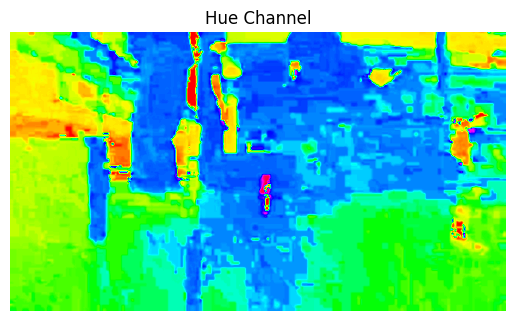

In [4]:
img = cv2.imread("captured_image_3.jpg")  #โหลดภาพ
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
h,s,v=cv2.split(image_hsv) #แยกHSV เป็น hue saturation value
h_blur = cv2.GaussianBlur(h, (7, 7), 0) #เลือกh มาเบลอเพื่อลดnoise
plt.imshow(h_blur,cmap='hsv')
plt.title('Hue Channel')
plt.axis('off')
plt.show()  #แสดงผล

# ทำให้เป็น binary

Text(0.5, 1.0, 'Binary Image')

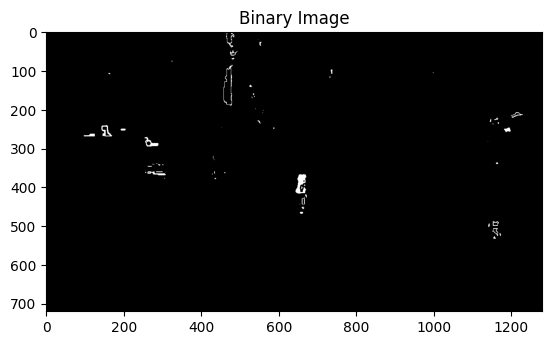

In [5]:
img_binary = ((h_blur > 0) & (h_blur < 10)) | ((h_blur > 140) & (h_blur < 180)) #ทำเป็นbinary โดยกำหนดสีที่ต้องการเป็นสีแดง
plt.imshow(img_binary, cmap='gray') #สีที่ตรงเงื่อนไขเป็นสีขาว ถ้าไม่เป็นสีดำ
plt.title('Binary Image') #แสดงผล

# โหลด bounding box(mask) 

Text(0.5, 1.0, 'Binary Image')

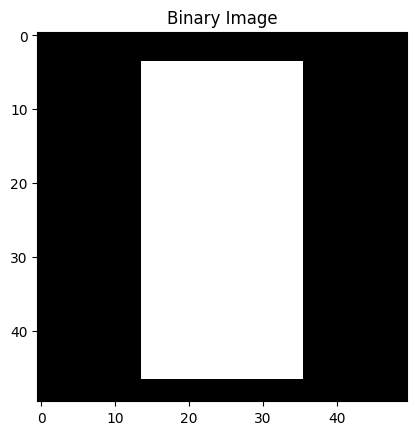

In [6]:
templat1=cv2.imread("bounding_box_1.jpg") #โหลดภาพ
template_hsv=cv2.cvtColor(templat1,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
template_h,template_s,template_v_1=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
template_binary1 = (template_v_1 > 100) #สร้างmask
plt.imshow(template_binary1, cmap='gray') #แสดงgrayscale
plt.title('Binary Image') #แสดงผล

templat2=cv2.imread("bounding_box_2.jpg") #โหลดภาพ
template_hsv=cv2.cvtColor(templat2,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
template_h,template_s,template_v_2=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
template_binary2 = (template_v_2 > 100) #สร้างmask
plt.imshow(template_binary2, cmap='gray') #แสดงgrayscale
plt.title('Binary Image') #แสดงผล

templat3=cv2.imread("bounding_box_3.jpg") #โหลดภาพ
template_hsv=cv2.cvtColor(templat3,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
template_h,template_s,template_v_3=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
template_binary3 = (template_v_3 > 100) #สร้างmask
plt.imshow(template_binary3, cmap='gray') #แสดงgrayscale
plt.title('Binary Image') #แสดงผล

# เลือกtemplateที่ตรงกันที่สุด และแสดงผล


In [ ]:
#เปลี่ยนเป็น uint8 เพื่อให้ สามารถใช้ cv2.matchTemplate ได้ โดยการ*255เพื่อปรับให้ 0(ขาว),255(ดำ) 
img_binary_uint8 = img_binary.astype(np.uint8) * 255
template_binary_uint8_1 = template_binary1.astype(np.uint8) * 255
template_binary_uint8_2 = template_binary2.astype(np.uint8) * 255
template_binary_uint8_3 = template_binary3.astype(np.uint8) * 255
#จับคู่ภาพกับtemplate โดยเลือกtemplate
value = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_1, cv2.TM_CCOEFF_NORMED)
value2 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_2, cv2.TM_CCOEFF_NORMED)
value3 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_3, cv2.TM_CCOEFF_NORMED)


In [9]:
#หาค่าสูงสุดของแต่ละสเกล
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(value)
min_val2, max_val2, min_loc2, max_loc2 = cv2.minMaxLoc(value2)
min_val3, max_val3, min_loc3, max_loc3 = cv2.minMaxLoc(value3)
#เลือกtemplateที่ตรงกันมากที่สุดมาแสดงผล
if max(max_val, max_val2, max_val3) == max_val:
    top_left = max_loc
    template_h, template_w = template_binary_uint8_1.shape
    max_val = max_val
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
elif max(max_val, max_val2, max_val3) == max_val2:
    top_left = max_loc2
    template_h, template_w = template_binary_uint8_2.shape
    max_val = max_val2
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
else:
    top_left = max_loc3
    template_h, template_w = template_binary_uint8_3.shape
    max_val = max_val3
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
cv2.rectangle(img, top_left, bottom_right, 255, 2) # วาดกรอบ
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # แสดงผล
plt.show()
print(max_val) # แสดงค่าที่ตรงกันมากที่สุด


error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'minMaxLoc'
> Overload resolution failed:
>  - src data type = bool is not supported
>  - Expected Ptr<cv::UMat> for argument 'src'


In [ ]:
def detect_red_object(img_read):
    img = cv2.imread(img_read)  #โหลดภาพ
    image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
    h,s,v=cv2.split(image_hsv) #แยกHSV เป็น hue saturation value
    h_blur = cv2.GaussianBlur(h, (7, 7), 0) #เลือกh มาเบลอเพื่อลดnoise

    img_binary = ((h_blur > 0) & (h_blur < 10)) | ((h_blur > 140) & (h_blur < 180)) #ทำเป็นbinary โดยกำหนดสีที่ต้องการเป็นสีแดง

    templat1=cv2.imread("bounding_box_1.jpg") #โหลดภาพ
    template_hsv=cv2.cvtColor(templat1,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
    template_h,template_s,template_v_1=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
    template_binary1 = (template_v_1 > 100) #สร้างmask
 

    templat2=cv2.imread("bounding_box_2.jpg") #โหลดภาพ
    template_hsv=cv2.cvtColor(templat2,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
    template_h,template_s,template_v_2=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
    template_binary2 = (template_v_2 > 100) #สร้างmask


    templat3=cv2.imread("bounding_box_3.jpg") #โหลดภาพ
    template_hsv=cv2.cvtColor(templat3,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
    template_h,template_s,template_v_3=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
    template_binary3 = (template_v_3 > 100) #สร้างmask

    #เปลี่ยนเป็น uint8 เพื่อให้ สามารถใช้ cv2.matchTemplate ได้ โดยการ*255เพื่อปรับให้ 0(ขาว),255(ดำ) 
    img_binary_uint8 = img_binary.astype(np.uint8) * 255
    template_binary_uint8_1 = template_binary1.astype(np.uint8) * 255
    template_binary_uint8_2 = template_binary2.astype(np.uint8) * 255
    template_binary_uint8_3 = template_binary3.astype(np.uint8) * 255
    #จับคู่ภาพกับtemplate โดยเลือกtemplate
    value = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_1, cv2.TM_CCOEFF_NORMED) > 0.5
    value2 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_2, cv2.TM_CCOEFF_NORMED) > 0.5
    value3 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_3, cv2.TM_CCOEFF_NORMED) > 0.5

    #หาค่าสูงสุดของแต่ละสเกล
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(value)
    min_val2, max_val2, min_loc2, max_loc2 = cv2.minMaxLoc(value2)
    min_val3, max_val3, min_loc3, max_loc3 = cv2.minMaxLoc(value3)
    #เลือกtemplateที่ตรงกันมากที่สุดมาแสดงผล
    if max(max_val, max_val2, max_val3) == max_val:
        top_left = max_loc
        template_h, template_w = template_binary_uint8_1.shape
        max_val = max_val
        bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
    elif max(max_val, max_val2, max_val3) == max_val2:
        top_left = max_loc2
        template_h, template_w = template_binary_uint8_2.shape
        max_val = max_val2
        bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
    else:
        top_left = max_loc3
        template_h, template_w = template_binary_uint8_3.shape
        max_val = max_val3
        bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
    cv2.rectangle(img, top_left, bottom_right, 255, 2) # วาดกรอบ
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # แสดงผล
    plt.show()
    print(max_val) # แสดงค่าที่ตรงกันมากที่สุด

# -*-coding:utf-8-*-
# Copyright (c) 2020 DJI.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License in the file LICENSE.txt or at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


import cv2
import robomaster
from robomaster import robot
from robomaster import vision


class RobotInfo:

    def __init__(self, x, y, w, h):
        self._x = x
        self._y = y
        self._w = w
        self._h = h

    @property
    def pt1(self):
        return int((self._x - self._w / 2) * 1280), int((self._y - self._h / 2) * 720)

    @property
    def pt2(self):
        return int((self._x + self._w / 2) * 1280), int((self._y + self._h / 2) * 720)

    @property
    def center(self):
        return int(self._x * 1280), int(self._y * 720)


robots = []


if __name__ == '__main__':
    ep_robot = robot.Robot()
    ep_robot.initialize(conn_type="ap")

    ep_vision = ep_robot.vision
    ep_camera = ep_robot.camera

    ep_camera.start_video_stream(display=False)
    result = ep_vision.sub_detect_info(name="robot", callback=detect_red_object)
    cv2.destroyAllWindows()
    result = ep_vision.unsub_detect_info(name="robot")
    cv2.destroyAllWindows()
    ep_camera.stop_video_stream()
    ep_robot.close()
